In [ ]:
using SpecialFunctions
using LinearAlgebra
using Plots, LaTeXStrings
using Struve
using KrylovKit
using SparseArrays
using Arpack  
using QuadGK
using ForwardDiff
using FFTW
using Statistics
using Measures
using Base.Threads
using TensorOperations
include("module_mos2_free_ph_plot.jl")
using .exciton

## Fig. 3a

In [ ]:
kx = 4pi / 3
ky = 0
θ = 0:0.1:2pi

strainlist = collect(-3:1/5:3)

rshift1 = similar(strainlist)
rshift2 = similar(strainlist)
rshift3 = similar(strainlist)
rshift4 = similar(strainlist)

for (i, strain_val) in enumerate(strainlist)
    th = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

    kdir = [cos(0), sin(0)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)

    rshift1[i] = rcv_shift[2] / rcvnorm

    rcv_shift = imag.(exciton.shiftvec([-kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([-kx, ky], kdir; epsilonyy=th, sz=1)
    rshift2[i] = rcv_shift[2] / rcvnorm

    kdir = [cos(pi / 2), sin(pi / 2)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)
    rshift3[i] = rcv_shift[2] / rcvnorm

end

rshift1_3=copy(rshift1)
rshift2_3=copy(rshift2)
rshift3_3=copy(rshift3)
strainlist_3=copy(strainlist);

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3a.png"

## Fig. 3a (inset)

In [9]:
kx = 4pi / 3
ky = 0
θlist = 0:0.05:pi

# Preallocate result array
rshift1 = zeros(Float64,length(θlist))
strain_val=0

for (i, theta) in enumerate(θlist)
    th = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

    kdir = [cos(theta), sin(theta)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)
    rshift1[i] = rcv_shift[2] / rcvnorm
end

rshift1_3a=copy(rshift1)
θlist_3a=copy(θlist);

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3ainset.png"

## Fig 3b

In [12]:
Nsample=60
lattice = GrapheneLattice();
#VInt = InteractionMatrix(lattice, Nsample; lambda=0.8, r0=4.28)
VInt = InteractionMatrix(lattice, Nsample; lambda=0.667, r0=4.288)
bi_1 = lattice.b1 / Nsample
bi_2 = lattice.b2 / Nsample
bi_3 = -bi_1 - bi_2
wb = 2 / (3 * norm(bi_1)^2)

45.594532639052

In [13]:
strainlist = collect(-3:1/5:3)

#strain_val = 5
#-(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

fulllist = Vector{Vector{ComplexF64}}(undef, length(strainlist))

for (i, strain_val) in enumerate(strainlist)
    epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
    println("This is $epsilonyy")
    graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz=1, epsilonyy)
    bloch_v, bloch_c1, bloch_c2 = graphene_sys.Bloch.valence, graphene_sys.Bloch.conduction1, graphene_sys.Bloch.conduction2
    bloch_states = [bloch_v]
    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))
    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    nbands = length(bloch_states)
    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands) # Initialization
    for xi = 1:Nsample, yi = 1:Nsample, nband_ind = 1:nbands
        U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
    end

    updated_Umn_mat = exciton.one_descent_step_singleband(U0mn_mat; M0_blist=M_blist, wb, varied_step=false, Nsample, blist, rlist, verbose=false)
    for steps = 1:200
        updated_Umn_mat = exciton.one_descent_step_singleband(updated_Umn_mat; M0_blist=M_blist, wb, varied_step=false, alphaval=0.1, Nsample, blist, rlist, verbose=false)
    end

    oldv = graphene_sys.Bloch.valence
    newv = 0 * oldv

    for xi = 1:Nsample, yi = 1:Nsample
        newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
    end

    bloch_states = [bloch_c1, bloch_c2]
    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    nbands = length(bloch_states)
    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands) # Initialization
    for xi = 1:Nsample, yi = 1:Nsample, nband_ind = 1:nbands
        U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
    end
    updated_Umn_mat = exciton.one_descent_step(U0mn_mat; M0_blist=M_blist, wb, nbands, Nsample, blist, rlist, verbose=false)
    for steps = 1:200
        updated_Umn_mat = exciton.one_descent_step(updated_Umn_mat; M0_blist=M_blist, wb, nbands, Nsample, blist, rlist, verbose=false)
    end

    oldc1 = graphene_sys.Bloch.conduction1
    oldc2 = graphene_sys.Bloch.conduction2
    newc1 = 0 * oldc1
    newc2 = 0 * oldc2

    for xi = 1:Nsample, yi = 1:Nsample
        newc1[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 1] * oldc2[xi, yi, :]
        newc2[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 2] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 2] * oldc2[xi, yi, :]
    end

    oldecv = graphene_sys.Bloch.ecvmat
    newecv = 0 * oldecv
    for xi = 1:Nsample, yi = 1:Nsample
        urotated = updated_Umn_mat[xi, yi, :, :]
        newecv[xi, yi, :, :] = urotated' * oldecv[xi, yi, :, :] * urotated
    end

    mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)
    graphene_sys = GrapheneBSE(graphene_sys.lattice, graphene_sys.kappa, graphene_sys.Nsample, mlwf_bloch, nothing, nothing)
    graphene_sys = add_bse_kernel(graphene_sys, VInt)
    bsemat = graphene_sys.BSEKernel
    xlen = size(bsemat)[1]
    x0 = rand(xlen)
    valslist, vecslist, info = eigsolve(bsemat, x0, 10, :SR,
        krylovdim=40, tol=1e-10, maxiter=20,
        verbosity=0, ishermitian=true)
    graphene_sys = add_wannier(graphene_sys)
    psik = vecslist[1]
    psi_real = exciton.envelope_real_fft(psik, graphene_sys)
    r1 = Rshift_calculator(graphene_sys, psi_real, 30)
    fulllist[i] = r1
end

This is 0.11206843337593364
gauge fixing successful!
[2.473891885766527e-7, -0.0016150617875511507]
This is 0.10462463134848055
gauge fixing successful!


LoadError: TaskFailedException

[91m    nested task error: [39mInterruptException:
    Stacktrace:
     [1] [0m[1mArray[22m
    [90m   @[39m [90m./[39m[90m[4mboot.jl:477[24m[39m[90m [inlined][39m
     [2] [0m[1mvect[22m
    [90m   @[39m [90m./[39m[90m[4marray.jl:163[24m[39m[90m [inlined][39m
     [3] [0m[1mmacro expansion[22m
    [90m   @[39m [90m~/numerical_library/github/exciton/src/fig3/[39m[90m[4mmodule_mos2_free_ph_plot.jl:434[24m[39m[90m [inlined][39m
     [4] [0m[1m(::Main.exciton.var"#84#threadsfor_fun#16"{Main.exciton.var"#84#threadsfor_fun#14#17"{Matrix{ComplexF64}, Array{Int64, 3}, BlochStates, Lattice2D, Vector{Float64}, Matrix{ComplexF64}, Int64, UnitRange{Int64}}})[22m[0m[1m([22m[90mtid[39m::[0mInt64; [90monethread[39m::[0mBool[0m[1m)[22m
    [90m   @[39m [36mMain.exciton[39m [90m./[39m[90m[4mthreadingconstructs.jl:215[24m[39m
     [5] [0m[1m#84#threadsfor_fun[22m
    [90m   @[39m [90m./[39m[90m[4m

## Multithread ver

In [14]:
using Base.Threads

strainlist = collect(-3:1/5:3)
fulllist = Vector{Vector{ComplexF64}}(undef, length(strainlist))

@threads for i in eachindex(strainlist)
    strain_val = strainlist[i]

    epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
    println("Thread $(threadid()): epsilonyy = $epsilonyy")

    graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz=1, epsilonyy)

    # ===== Valence band =====
    bloch_v = graphene_sys.Bloch.valence
    bloch_states = [bloch_v]

    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] *
            angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
    @inbounds for xi = 1:Nsample, yi = 1:Nsample
        U0mn_mat[xi, yi, 1, 1] = 1
    end

    updated_Umn_mat = exciton.one_descent_step_singleband(
        U0mn_mat; M0_blist=M_blist, wb,
        varied_step=false, Nsample, blist, rlist, verbose=false
    )

    for _ = 1:200
        updated_Umn_mat = exciton.one_descent_step_singleband(
            updated_Umn_mat; M0_blist=M_blist, wb,
            varied_step=false, alphaval=0.1,
            Nsample, blist, rlist, verbose=false
        )
    end

    oldv = graphene_sys.Bloch.valence
    newv = similar(oldv)
    @inbounds for xi = 1:Nsample, yi = 1:Nsample
        newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
    end

    # ===== Conduction bands =====
    bloch_c1 = graphene_sys.Bloch.conduction1
    bloch_c2 = graphene_sys.Bloch.conduction2
    bloch_states = [bloch_c1, bloch_c2]

    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] *
            angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
    @inbounds for xi = 1:Nsample, yi = 1:Nsample, n = 1:nbands
        U0mn_mat[xi, yi, n, n] = 1
    end

    updated_Umn_mat = exciton.one_descent_step(
        U0mn_mat; M0_blist=M_blist, wb,
        nbands, Nsample, blist, rlist, verbose=false
    )

    for _ = 1:200
        updated_Umn_mat = exciton.one_descent_step(
            updated_Umn_mat; M0_blist=M_blist, wb,
            nbands, Nsample, blist, rlist, verbose=false
        )
    end

    newc1 = similar(bloch_c1)
    newc2 = similar(bloch_c2)

    @inbounds for xi = 1:Nsample, yi = 1:Nsample
        U = updated_Umn_mat[xi, yi, :, :]
        newc1[xi, yi, :] = U[1,1]*bloch_c1[xi, yi, :] + U[2,1]*bloch_c2[xi, yi, :]
        newc2[xi, yi, :] = U[1,2]*bloch_c1[xi, yi, :] + U[2,2]*bloch_c2[xi, yi, :]
    end

    oldecv = graphene_sys.Bloch.ecvmat
    newecv = similar(oldecv)

    @inbounds for xi = 1:Nsample, yi = 1:Nsample
        U = updated_Umn_mat[xi, yi, :, :]
        newecv[xi, yi, :, :] = U' * oldecv[xi, yi, :, :] * U
    end

    mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)
    graphene_sys = GrapheneBSE(
        graphene_sys.lattice, graphene_sys.kappa,
        graphene_sys.Nsample, mlwf_bloch, nothing, nothing
    )

    graphene_sys = add_bse_kernel(graphene_sys, VInt)
    bsemat = graphene_sys.BSEKernel

    x0 = rand(size(bsemat, 1))
    valslist, vecslist, _ = eigsolve(
        bsemat, x0, 10, :SR;
        krylovdim=40, tol=1e-10,
        maxiter=20, verbosity=0, ishermitian=true
    )

    graphene_sys = add_wannier(graphene_sys)
    psi_real = exciton.envelope_real_fft(vecslist[1], graphene_sys)
    fulllist[i] = Rshift_calculator(graphene_sys, psi_real, 30)
end


Thread 2: epsilonyy = 0.05240715094703863
Thread 4: epsilonyy = -0.06764984978244071
Thread 3: epsilonyy = -0.007501872191362224
Thread 1: epsilonyy = 0.11206843337593364
gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
[2.473891896272321e-7, -0.0016150617875432067]
Thread 1: epsilonyy = 0.10462463134848055
gauge fixing successful!
[2.260585945343692e-7, -0.0007826005958286134]
Thread 1: epsilonyy = 0.04493188745099075
gauge fixing successful!
[2.518502107661221e-7, 0.0010230434526892977]
Thread 2: epsilonyy = -0.07518472570210988
gauge fixing successful!
[2.2607637761661908e-7, 0.00011407034314423092]
Thread 4: epsilonyy = -0.015007477561723714
gauge fixing successful!
[2.436110462565871e-7, -0.0015160311274611078]
Thread 2: epsilonyy = 0.09717683370081165
gauge fixing successful!
[2.2484540895779261e-7, -0.0006730642456247005]
Thread 1: epsilonyy = 0.03745277100559996
gauge fixing successful!
[2.2774248943873202e-7, 0.000228196446139

In [15]:
shifty = zeros(Float64, length(fulllist))
for j = 1:length(shifty)
    shifty[j] = real.(fulllist)[j][2]
end
shifty_3b=copy(shifty)

31-element Vector{Float64}:
 -0.0016150617875432067
 -0.0015160311274611078
 -0.001415409195450081
 -0.001313270244848962
 -0.001209691113997627
 -0.001104751238375817
 -0.0009985326585450426
 -0.0008911200237785457
 -0.0007826005958286134
 -0.0006730642456247005
 -0.0005626034495540528
 -0.0004513132812222718
 -0.0003392914006996714
  ⋮
  0.0004566105004656491
  0.000570665526341508
  0.0006844599306552213
  0.0007978712847145611
  0.0009107748201616179
  0.0010230434526892977
  0.0011345478037543435
  0.0012451562191013706
  0.001354734783577292
  0.0014631473304528584
  0.001570255445818356
  0.001675918464553423

In [94]:
-(sqrt((1 + 2.66 / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

-0.10007517101463859

In [16]:
fulllist = Vector{Vector{ComplexF64}}(undef, length(strainlist))

for (i, strain_val) in enumerate(strainlist)
    epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
    println("This is $epsilonyy")
    graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz=-1, epsilonyy)
    bloch_v, bloch_c1, bloch_c2 = graphene_sys.Bloch.valence, graphene_sys.Bloch.conduction1, graphene_sys.Bloch.conduction2
    bloch_states = [bloch_v]
    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))
    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    nbands = length(bloch_states)
    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands) # Initialization
    for xi = 1:Nsample, yi = 1:Nsample, nband_ind = 1:nbands
        U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
    end

    updated_Umn_mat = exciton.one_descent_step_singleband(U0mn_mat; M0_blist=M_blist, wb, varied_step=false, Nsample, blist, rlist, verbose=false)
    for steps = 1:200
        updated_Umn_mat = exciton.one_descent_step_singleband(updated_Umn_mat; M0_blist=M_blist, wb, varied_step=false, alphaval=0.1, Nsample, blist, rlist, verbose=false)
    end

    oldv = graphene_sys.Bloch.valence
    newv = 0 * oldv

    for xi = 1:Nsample, yi = 1:Nsample
        newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
    end

    bloch_states = [bloch_c1, bloch_c2]
    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    nbands = length(bloch_states)
    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands) # Initialization
    for xi = 1:Nsample, yi = 1:Nsample, nband_ind = 1:nbands
        U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
    end
    updated_Umn_mat = exciton.one_descent_step(U0mn_mat; M0_blist=M_blist, wb, nbands, Nsample, blist, rlist, verbose=false)
    for steps = 1:200
        updated_Umn_mat = exciton.one_descent_step(updated_Umn_mat; M0_blist=M_blist, wb, nbands, Nsample, blist, rlist, verbose=false)
    end

    oldc1 = graphene_sys.Bloch.conduction1
    oldc2 = graphene_sys.Bloch.conduction2
    newc1 = 0 * oldc1
    newc2 = 0 * oldc2

    for xi = 1:Nsample, yi = 1:Nsample
        newc1[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 1] * oldc2[xi, yi, :]
        newc2[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 2] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 2] * oldc2[xi, yi, :]
    end

    oldecv = graphene_sys.Bloch.ecvmat
    newecv = 0 * oldecv
    for xi = 1:Nsample, yi = 1:Nsample
        urotated = updated_Umn_mat[xi, yi, :, :]
        newecv[xi, yi, :, :] = urotated' * oldecv[xi, yi, :, :] * urotated
    end

    mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)
    graphene_sys = GrapheneBSE(graphene_sys.lattice, graphene_sys.kappa, graphene_sys.Nsample, mlwf_bloch, nothing, nothing)
    graphene_sys = add_bse_kernel(graphene_sys, VInt)
    bsemat = graphene_sys.BSEKernel
    xlen = size(bsemat)[1]
    x0 = rand(xlen)
    valslist, vecslist, info = eigsolve(bsemat, x0, 10, :SR,
        krylovdim=40, tol=1e-10, maxiter=20,
        verbosity=0, ishermitian=true)
    graphene_sys = add_wannier(graphene_sys)
    psik = vecslist[2]
    psi_real = exciton.envelope_real_fft(psik, graphene_sys)
    r1 = Rshift_calculator(graphene_sys, psi_real, 30)
    fulllist[i] = r1
end

This is 0.11206843337593364
gauge fixing successful!
[5.384387150480925e-8, -0.0012080319369874673]
This is 0.10462463134848055
gauge fixing successful!
[5.214340703452108e-8, -0.0011355829852418879]
This is 0.09717683370081165
gauge fixing successful!
[5.0552649860062326e-8, -0.0010616759078037117]
This is 0.08972505861433444
gauge fixing successful!
[4.906852032012934e-8, -0.0009863754230505437]
This is 0.08226932416993793
gauge fixing successful!
[4.7688392378831326e-8, -0.0009097479262718676]
This is 0.07480964834860437
gauge fixing successful!
[4.64095150453842e-8, -0.0008318615068553476]
This is 0.06734604903202268
gauge fixing successful!
[4.522946522719712e-8, -0.0007527859638397728]
This is 0.05987854400319459
gauge fixing successful!
[4.4145815705807774e-8, -0.0006725928197583273]
This is 0.05240715094703863
gauge fixing successful!
[4.315695347420542e-8, -0.000591355332950835]
This is 0.04493188745099075
gauge fixing successful!
[4.2260487548267144e-8, -0.0005091485084271162

In [18]:
shifty_2 = zeros(Float64, length(fulllist))
for j = 1:length(shifty_2)
    shifty_2[j] = real.(fulllist)[j][2]
end
shifty_2_3b=copy(shifty_2)

31-element Vector{Float64}:
 -0.0012080319369874673
 -0.0011355829852418879
 -0.0010616759078037117
 -0.0009863754230505437
 -0.0009097479262718676
 -0.0008318615068553476
 -0.0007527859638397728
 -0.0006725928197583273
 -0.000591355332950835
 -0.0005091485084271162
 -0.00042604910724736535
 -0.0003421356544472833
 -0.0002574884461836689
  ⋮
  0.0003484680160440931
  0.00043588044797548156
  0.0005232234759150691
  0.0006103988237836029
  0.0006973063783419895
  0.0007838441744447126
  0.0008699083757335141
  0.0009553932509289985
  0.001040191144315347
  0.0011241924390580933
  0.0012072855129195625
  0.0012893566846400315

In [20]:
strainlist_3b=copy(strainlist);

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3b.png"

## Fig 3c

## Exciton shift current subroutine

# Below is computing shift current

In [23]:
gamma_value=0.02

0.02

In [24]:
EF = 2.5
epsilonyy = -0.1
th_angle_list = collect(0:pi/30:pi)
free_ph_shift_list = Vector{Float64}(undef, length(th_angle_list))
for (i,th_angle) in enumerate(th_angle_list)
    shift_current_integration = [0, 0]
    nsize = 60
    for sz in [-1, 1]
        for xi = 1:nsize, yi = 1:nsize
            k = (xi * lattice.b1 + yi * lattice.b2) / nsize
            valslist, vecslist = eigen(exciton.TMD_hnn(k; epsilonyy, sz))
            ecv = valslist[3] - valslist[1]
            rcv_shift = imag.(exciton.shiftvec_higher(k, [cos(th_angle), sin(th_angle)]; epsilonyy, sz))
            shift_current_integration += rcv_shift * gamma_value ./ pi ./ ((ecv - EF)^2 + gamma_value^2)
            
            ecv = valslist[2] - valslist[1]
            rcv_shift = imag.(exciton.shiftvec(k, [cos(th_angle), sin(th_angle)]; epsilonyy, sz))
            shift_current_integration += rcv_shift * gamma_value ./ pi ./ ((ecv - EF)^2 + gamma_value^2)
        end
    end
    println("This is $th_angle")
    free_ph_shift_list[i]=real(shift_current_integration[2]) * abs(lattice.b1[1] * lattice.b2[2] - lattice.b1[2] * lattice.b2[1]) / nsize^2 * 9 / 100 * 1.6 * 3.16 / 2pi / EF^2 / 6.58 * 1e2
end

This is 0.0
This is 0.10471975511965977
This is 0.20943951023931953
This is 0.3141592653589793
This is 0.41887902047863906
This is 0.5235987755982988
This is 0.6283185307179586
This is 0.7330382858376183
This is 0.8377580409572781
This is 0.9424777960769379
This is 1.0471975511965976
This is 1.1519173063162573
This is 1.2566370614359172
This is 1.361356816555577
This is 1.4660765716752366
This is 1.5707963267948966
This is 1.6755160819145563
This is 1.780235837034216
This is 1.8849555921538759
This is 1.9896753472735356
This is 2.0943951023931953
This is 2.199114857512855
This is 2.3038346126325147
This is 2.4085543677521746
This is 2.5132741228718345
This is 2.617993877991494
This is 2.722713633111154
This is 2.827433388230814
This is 2.9321531433504733
This is 3.036872898470133
This is 3.141592653589793


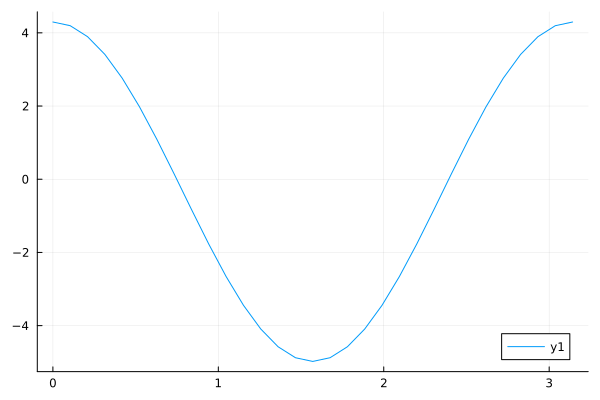

In [25]:
plot(th_angle_list, free_ph_shift_list)

In [28]:
th_angle_list_3c=copy(th_angle_list)
free_ph_shift_list_3c=copy(free_ph_shift_list);

In [29]:
p = hline([0], color=:black, ls=:dash, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(-5.5, 5), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(p, th_angle_list_3c, free_ph_shift_list_3c, framestyle=:box, xgrid=false, ygrid=false, label=false, tickfontsize=15, markershape=:diamond, color=:blue, dpi=800, size=(400, 280))
savefig(p, "fig3c.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3c.png"

## Fig 3d

In [30]:
Nsample = 60
epsilonyy = -0.1
th_angle_list = collect(0:pi/30:pi)

exciton_shift_list = Vector{Float64}(undef, length(th_angle_list))

for (i, th_angle) in enumerate(th_angle_list)
    println("This is $th_angle")
    exciton_shift_list[i] =  exciton.exciton_shift_current_subroutine(Nsample, epsilonyy, 1, th_angle) + exciton.exciton_shift_current_subroutine(Nsample, epsilonyy, -1, th_angle)
end

This is 0.0
gauge fixing successful!
[2.799761730549245e-7, 0.0014943536127923207]
gauge fixing successful!
[3.7251017080626327e-7, 0.0014944321779049622]
This is 0.10471975511965977
gauge fixing successful!
[2.799761718377852e-7, 0.0014943536127906129]
gauge fixing successful!
[3.725101623545355e-7, 0.0014944321779003086]
This is 0.20943951023931953
gauge fixing successful!
[2.7997617133790895e-7, 0.0014943536127986067]
gauge fixing successful!
[3.7251018031611567e-7, 0.001494432177913661]
This is 0.3141592653589793
gauge fixing successful!
[2.7997616853699816e-7, 0.0014943536127923918]
gauge fixing successful!
[3.725101757997918e-7, 0.001494432177911379]
This is 0.41887902047863906
gauge fixing successful!
[2.799761715365704e-7, 0.0014943536127924664]
gauge fixing successful!
[3.725101816047092e-7, 0.001494432177914488]
This is 0.5235987755982988
gauge fixing successful!
[2.7997616425592773e-7, 0.0014943536127900454]
gauge fixing successful!
[3.725101851699692e-7, 0.00149443217791495

In [32]:
th_angle_list_3d=copy(th_angle_list)
exciton_shift_list_3d=copy(exciton_shift_list);

In [33]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(0, 0.21), yticks=([0, 0.1, 0.2]), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(th_angle_list_3d, exciton_shift_list_3d .* 9 ./ 100, framestyle=:box, xgrid=false, ygrid=false, label=false, tickfontsize=15, dpi=800, size=(400, 280))
savefig("fig3d.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3d.png"

In [ ]:
for i ∈ 1:Nsample
	for j ∈ 1:Nsample
		k = (i * b1 + j * b2) / Nsample
		mat = TMD_hnn(k; sz=1, epsilonyy=0)
		eige, eigv = eigen(mat)
		vk, c2k, c1k = eachcol(eigv)
		Bloch_conduction1[i, j, :] = c1k
		Bloch_conduction2[i, j, :] = c2k
		Bloch_valence[i, j, :] = vk
		E_cv[i, j, 1, 1] = (eige[3] - eige[1])
		E_cv[i, j, 2, 2] = (eige[2] - eige[1])
	end
end


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///Users/xuyang/numerical_library/github/exciton/src/fig3/In[1]#12:12\[90mIn[1]:12:12[0;0m]8;;\
            E_cv[i, j, 2, 2] = (eige[2] - eige[1])
        end[48;2;120;70;70m[0;0m
[90m#          └ ── [0;0m[91mExpected `end`[0;0m

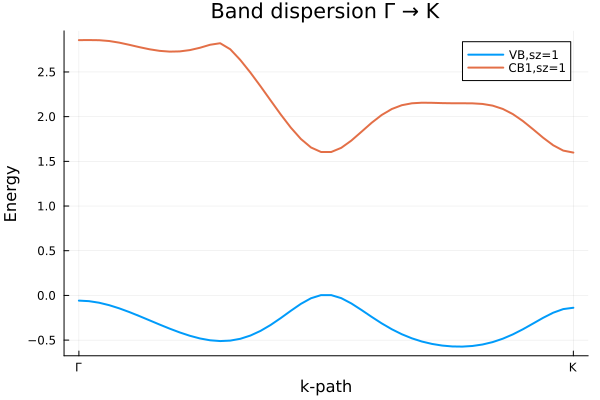

In [15]:
using LinearAlgebra
using Plots

# -----------------------------
# Reciprocal lattice vectors
# -----------------------------
# (Replace these with YOUR actual b1, b2 if already defined)
lattice = GrapheneLattice();
b1 = lattice.b1
b2 = lattice.b2

# -----------------------------
# High-symmetry points
# -----------------------------
Γ = zeros(2)
K = (2b1 + b2) / 3

# -----------------------------
# k-path: Γ → K
# -----------------------------
Npath = 50
kpath = [ (1 - t) * Γ + t * K for t in range(0, 2, length=Npath) ]

# -----------------------------
# Storage
# -----------------------------
nband = 3
Ebands = zeros(Npath, nband)

# -----------------------------
# Diagonalize along path
# -----------------------------
for (n, k) in enumerate(kpath)
    Hk = exciton.TMD_hnn(k; sz=1, epsilonyy=0)
    Ebands[n, :] .= real.(eigen(Hk).values)
end

# -----------------------------
# Plot
# -----------------------------
x = range(0, 1, length=Npath)

plot(
    x, Ebands[:,1],
    lw=2, label="VB,sz=1",
    xlabel="k-path",
    ylabel="Energy"
)
plot!(x, Ebands[:,2], lw=2, label="CB1,sz=1")

xticks!([0, 1], ["Γ", "K"])
title!("Band dispersion Γ → K")


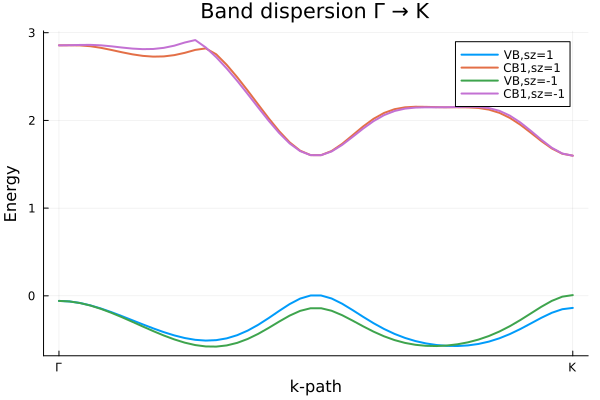

In [16]:
# -----------------------------
# High-symmetry points
# -----------------------------
Γ = zeros(2)
K = (2b1 + b2) / 3

# -----------------------------
# k-path: Γ → K
# -----------------------------
Npath = 50
kpath = [ (1 - t) * Γ + t * K for t in range(0, 2, length=Npath) ]

# -----------------------------
# Storage
# -----------------------------
nband = 3
Ebands = zeros(Npath, nband)

# -----------------------------
# Diagonalize along path
# -----------------------------
for (n, k) in enumerate(kpath)
    Hk = exciton.TMD_hnn(k; sz=-1, epsilonyy=0)
    Ebands[n, :] .= real.(eigen(Hk).values)
end

# -----------------------------
# Plot
# -----------------------------
x = range(0, 1, length=Npath)

plot!(
    x, Ebands[:,1],
    lw=2, label="VB,sz=-1",
    xlabel="k-path",
    ylabel="Energy"
)
plot!(x, Ebands[:,2], lw=2, label="CB1,sz=-1")

In [46]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-3.1, 3.1), xticks=([-3,-2,-1 ,0, 1,2,3]))

# Vertical axis at x = 0
vline!([0], color=:black, lw=0.5, label=false)
scatter!(strainlist_3, [rshift1_3 rshift2_3 rshift3_3] .* 100, framestyle=:box, xgrid=false, ylim=(-7, 7), legendfontsize=7, yticks=([-6, -3, 0, 3, 6]), ygrid=false,lw=3, label=[L"K, \theta=0,S_z=+1/2" L"K', \theta=0,S_z=+1/2" L"K, \theta=\pi/2,S_z=+1/2"],ls=[:dash :solid :dashdot], tickfontsize=15, dpi=800, size=(360, 320))
#color = [:red :blue :green :orange],
savefig("fig3a.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3a.png"

In [37]:
θlist_3a

0.0:0.05:3.1

In [51]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi+0.1), xticks=([0, pi/2,pi],["0", L"\pi/2", L"\pi"]))

# Vertical axis at x = 0
#vline!([0], color=:black, lw=0.5, label=false)
scatter!(θlist_3a, rshift1_3a .* 100, framestyle=:box, xgrid=false, ylim=(-1.5, 1.5), legendfontsize=17, yticks=([-1, 0, 1]), ygrid=false, label=L"K, S_z=+1/2", tickfontsize=25, dpi=800, size=(300, 300))

savefig("fig3ainset.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3ainset.png"

In [50]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-3.1, 3.1), ylim=(-0.22, 0.22), xticks=([-3, -2,-1, 0,1,2, 3]))

# Vertical axis at x = 0
vline!([0], color=:black, lw=0.5, label=false)
#scatter!(strainlist, [shifty, shifty_2] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=15, dpi=800, size=(400, 280))
scatter!(strainlist_3b, [shifty_3b, shifty_2_3b] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=12, dpi=800, size=(360, 320))

savefig("fig3b.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3b.png"

In [52]:
p = hline([0], color=:black, ls=:dash, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(-5.5, 5), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(p, th_angle_list_3c, free_ph_shift_list_3c, framestyle=:box, xgrid=false, ygrid=false, label=false, tickfontsize=12, markershape=:diamond, color=:blue, dpi=800, size=(360, 320))
savefig(p, "fig3c.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3c.png"

In [49]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(0, 0.21), yticks=([0, 0.1, 0.2]), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(th_angle_list_3d, exciton_shift_list_3d .* 9 ./ 100, framestyle=:box, xgrid=false, ygrid=false, label=false, tickfontsize=15, dpi=800, size=(360, 320))
savefig("fig3d.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3d.png"